## City wide validation 

This notebook validates mean velocites on city level

In [20]:
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import shapely
import builtins
import re

In [11]:
augmenterra_data_dir = Path("/home/lukas/projects/ADUCAT/data/Augmenterra/processed")
own_insar_data_dir = Path("/home/lukas/projects/ADUCAT/data/final_outputs")
egms_data_dir = Path("/home/lukas/projects/ADUCAT/data/EGMS/vienna/processed")

print("Reference data directory:", augmenterra_data_dir)
print("Own processed data directory:", own_insar_data_dir)
print("EGMS data directory:", egms_data_dir)

Reference data directory: /home/lukas/projects/ADUCAT/data/Augmenterra/processed
Own processed data directory: /home/lukas/projects/ADUCAT/data/final_outputs
EGMS data directory: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed


In [37]:
orbit_direction = "ASC"
orbit = "073"


ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

ref_egms_file = Path(egms_data_dir, f"EGMS_{orbit}_2020_2024.parquet")
print("EGMS reference data file:", ref_egms_file)

processed_data_file = Path(own_insar_data_dir, "download-isce2-new-xc6vs_result2.parquet")
print("Own processed data file:", processed_data_file)

aoi_city_file = Path("/home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg")
print("AOI city file:", aoi_city_file)


Augmenterra reference data file: /home/lukas/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC.parquet
EGMS reference data file: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed/EGMS_073_2020_2024.parquet
Own processed data file: /home/lukas/projects/ADUCAT/data/final_outputs/download-isce2-new-xc6vs_result2.parquet
AOI city file: /home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg


In [38]:
# ============================================================
# Columns to load
# ============================================================

# AUGMENTERRA 
 
AUGMENTERRA_VELOCITY_COL = "VEL_20220101_20241231"
AUGMENTERRA_COHERENCE_COL = "COHERENCE"
AUGMENTERRA_GEOMETRY_COL = "geometry"

augmenterra_cols = [
    AUGMENTERRA_VELOCITY_COL,
    AUGMENTERRA_COHERENCE_COL,
    AUGMENTERRA_GEOMETRY_COL
]

# EGMS

EGMS_VELOCITY_COL = "mean_velocity"
EGMS_COHERENCE_COL = "temporal_coherence"
EGMS_GEOMETRY_COL = "geometry"

egms_cols = [
    EGMS_VELOCITY_COL,
    EGMS_COHERENCE_COL,
    EGMS_GEOMETRY_COL
]

# OWN PROCESSED DATA


PROCESSED_VELOCITY_COL = "VEL"
PROCESSED_COHERENCE_COL = "COHERENCE"
PROCESSED_GEOMETRY_COL = "geometry"

processed_cols = [
    PROCESSED_VELOCITY_COL,
    PROCESSED_COHERENCE_COL,
    PROCESSED_GEOMETRY_COL
]

Load AOI city geopackage

In [39]:
aoi_city = gpd.read_file(aoi_city_file)

# Convert to EPSG:4326
aoi_city = aoi_city.to_crs("EPSG:4326")
print(aoi_city.crs)

# convert AOI city geometry to EPSG:4326 and extract the first geometry
aoi_polygon = aoi_city.geometry.iloc[0]

print("AOI city geometry:", aoi_polygon)
print(type(aoi_polygon))

EPSG:4326
AOI city geometry: MULTIPOLYGON (((16.45342772507055 48.29727414692325, 16.453432875672 48.299522411683824, 16.4534380269105 48.30177067556145, 16.45344317878614 48.304018938556176, 16.45344833129904 48.306267200668046, 16.453453484449287 48.308515461896974, 16.453458638236974 48.310763722243045, 16.45346379266221 48.31301198170626, 16.453468947725085 48.3152602402866, 16.453474103425716 48.31750849798409, 16.45347925976419 48.31975675479874, 16.453484416740615 48.32200501073056, 16.453489574355075 48.32425326577953, 16.45011834885512 48.32425665617854, 16.446747122735218 48.324259947770585, 16.44337589601355 48.324263140555644, 16.440004668708333 48.324266234533674, 16.43663344083776 48.32426922970462, 16.433262212420026 48.32427212606847, 16.429890983473335 48.32427492362516, 16.426519754015885 48.32427762237466, 16.42314852406587 48.324280222316936, 16.419777293641495 48.32428272345196, 16.416406062760952 48.32428512577967, 16.41303483144244 48.32428742930005, 16.409663599

## Functions

In [40]:
def extract_points_in_polygon(
    parquet_file,
    polygon,
    polygon_crs="EPSG:4326",
    columns=None,
    data_crs="EPSG:4326"
):

    parquet = pq.ParquetFile(parquet_file)

    n_groups = parquet.num_row_groups

    print(f"Rows:       {parquet.metadata.num_rows:,}")
    print(f"Row groups: {n_groups}")
    print()

    # --------------------------------------------------------
    # Transform polygon to the CRS of the Parquet data
    # --------------------------------------------------------

    if polygon_crs != data_crs:

        polygon_gdf = gpd.GeoDataFrame(
            geometry=[polygon],
            crs=polygon_crs
        )

        polygon = polygon_gdf.to_crs(data_crs).geometry.iloc[0]

    # --------------------------------------------------------
    # Select columns
    # --------------------------------------------------------

    if columns is not None:

        columns = list(columns)

        if "geometry" not in columns:
            columns.append("geometry")

    results = []

    # --------------------------------------------------------
    # Process row groups
    # --------------------------------------------------------

    for i in builtins.range(n_groups):

        table = parquet.read_row_group(
            i,
            columns=columns
        )

        df = table.to_pandas()

        # WKB -> Shapely
        geometry = shapely.from_wkb(
            df["geometry"].to_numpy()
        )

        # Spatial filter
        mask = shapely.intersects(
            geometry,
            polygon
        )

        n_matches = int(mask.sum())

        if n_matches > 0:

            matched = df.loc[mask].copy()
            matched["geometry"] = geometry[mask]

            results.append(matched)

        print(
            f"Row group {i + 1:3d}/{n_groups}: "
            f"{n_matches:,} points inside"
        )

    # --------------------------------------------------------
    # Combine results
    # --------------------------------------------------------

    if results:

        result = pd.concat(
            results,
            ignore_index=True
        )

        return gpd.GeoDataFrame(
            result,
            geometry="geometry",
            crs=data_crs
        )

    # No points found
    return gpd.GeoDataFrame(
        columns=columns if columns is not None else parquet.schema.names,
        geometry="geometry",
        crs=data_crs
    )


## Load data

In [41]:
augmenterra = gpd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols
)

egms = extract_points_in_polygon(
    ref_egms_file,
    aoi_polygon,
    columns=egms_cols
)

processed = extract_points_in_polygon(
    processed_data_file,
    aoi_polygon,
    columns=processed_cols
)

Rows:       1,446,002
Row groups: 17

Row group   1/17: 52,229 points inside
Row group   2/17: 97,042 points inside
Row group   3/17: 95,710 points inside
Row group   4/17: 85,751 points inside
Row group   5/17: 58,183 points inside
Row group   6/17: 26,395 points inside
Row group   7/17: 99,242 points inside
Row group   8/17: 99,909 points inside
Row group   9/17: 99,931 points inside
Row group  10/17: 99,991 points inside
Row group  11/17: 99,214 points inside
Row group  12/17: 98,441 points inside
Row group  13/17: 99,392 points inside
Row group  14/17: 93,082 points inside
Row group  15/17: 9,210 points inside
Row group  16/17: 39,216 points inside
Row group  17/17: 0 points inside
Rows:       670,071
Row groups: 21

Row group   1/21: 0 points inside
Row group   2/21: 0 points inside
Row group   3/21: 1,235 points inside
Row group   4/21: 20,724 points inside
Row group   5/21: 45,273 points inside
Row group   6/21: 47,117 points inside
Row group   7/21: 45,922 points inside
Row gro

In [42]:
processed.head()

,VEL,COHERENCE,geometry
0,-18.978948,0.926077,POINT (16.52671 48.13625)
1,-15.369507,0.906998,POINT (16.52123 48.13585)
2,-17.103702,0.941122,POINT (16.52144 48.13587)
3,-12.957951,0.927838,POINT (16.52165 48.13589)
4,9.817093,0.943345,POINT (16.52186 48.13592)


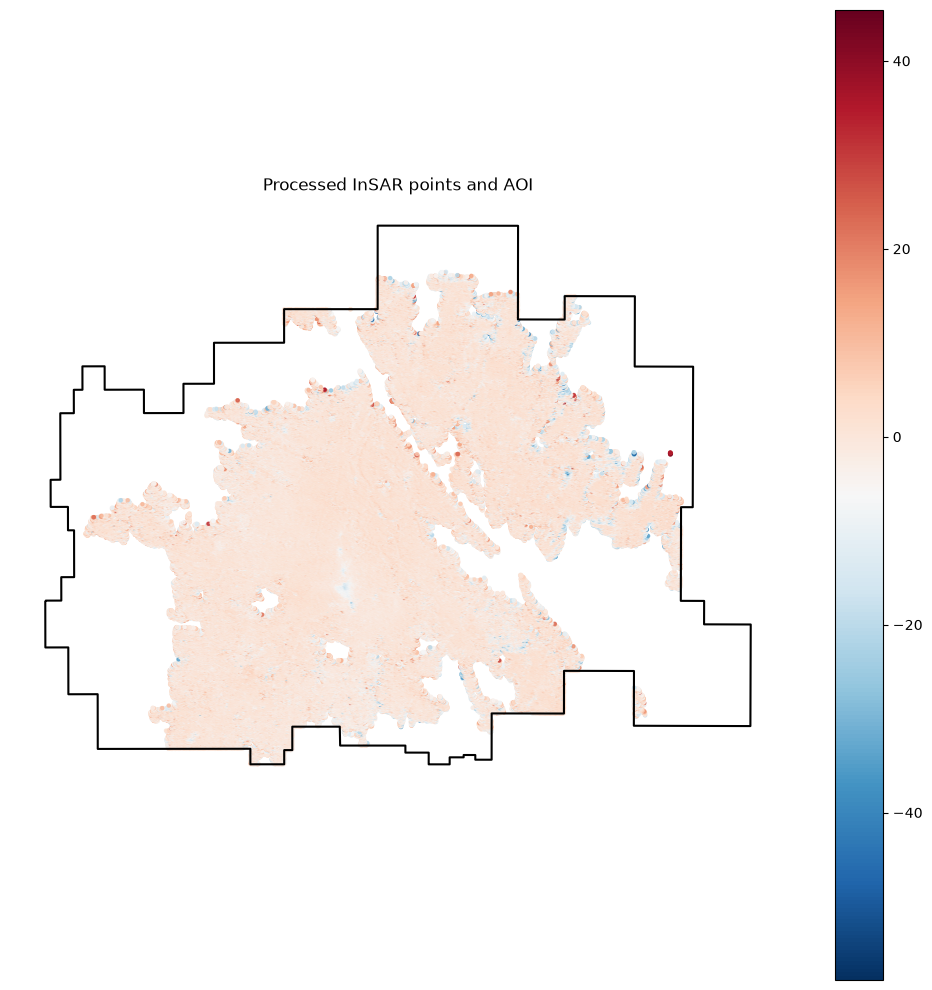

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))

# Processed points
processed.plot(
    ax=ax,
    column="VEL",
    cmap="RdBu_r",
    legend=True,
    markersize=5,
    alpha=0.8
)

# AOI boundary
aoi_city.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

ax.set_title("Processed InSAR points and AOI")
ax.set_axis_off()

plt.tight_layout()
plt.show()